In [83]:
import pandas as pd
import io
import re
import glob
import matplotlib.pyplot as plt
import os
from collections import Counter
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from collections import defaultdict


vcf_directory = '/Users/fionachow/Documents/NYU/CDS/Summer 2024/Human rDNA Research/Project/Human-rDNA/original reference/original_vcf_all/'
data_csv_path = '/Users/fionachow/Documents/NYU/CDS/Summer 2024/Human rDNA Research/Project/Human-rDNA/original reference/1000data.csv'

metadata_df = pd.read_csv(data_csv_path)

# Create a dictionary to map Run to Population
run_to_population = dict(zip(metadata_df['Run'], metadata_df['population']))

# Calculate overall population distribution
total_population_count = metadata_df['population'].value_counts(normalize=True).to_dict()

def parse_vcf(file):
    vcf_df = pd.read_csv(file, comment='#', delimiter='\t', header=None,
                         names=['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO'])
    # Extract the Run from the filename
    run_id = os.path.basename(file).split('_')[0]
    
    # Add population information to the VCF DataFrame
    vcf_df['population'] = run_to_population.get(run_id, 'Unknown')
    vcf_df['Run'] = run_id
    
    return vcf_df

def extract_af(info):
    match = re.search(r'AF=([\d\.]+)', info)
    return match.group(1) if match else None

def is_in_regions(pos):
    for start, end, _ in all_positions:
        if start <= pos <= end:
            return True
    return False

all_positions = [
    [1, 3656, "5'ETS"],
    [3657, 5527, '18S'],
    [5528, 6622, 'ITS1'],
    [6623, 6779, '5.8S'],
    [6780, 7934, 'ITS2'],
    [7935, 12969, '28S'],
    [12970, 13314, "3'ETS"]
]

In [84]:
# List to store data
shared_variants = {} #e.g. {'human_31_A_G': 3, 'human_33_C_G': 1, etc}

# Parse all VCF files and extract AF values
vcf_files = glob.glob(vcf_directory + '*.vcf')
for vcf_file in vcf_files:
    df = parse_vcf(vcf_file)
    df['AF'] = df['INFO'].apply(extract_af)
    df = df[df['POS'].apply(is_in_regions)]
    for _, row in df.iterrows():
        key = (row['CHROM'], row['POS'], row['REF'], row['ALT'])
        population = row['population']
        run_id = row['Run']
        if key not in shared_variants:
            shared_variants[key] = []
        shared_variants[key].append(run_id)

# Prepare data for plotting
variant_counts = [len(val) for val in shared_variants.values()]  #e.g. [3, 1,...]


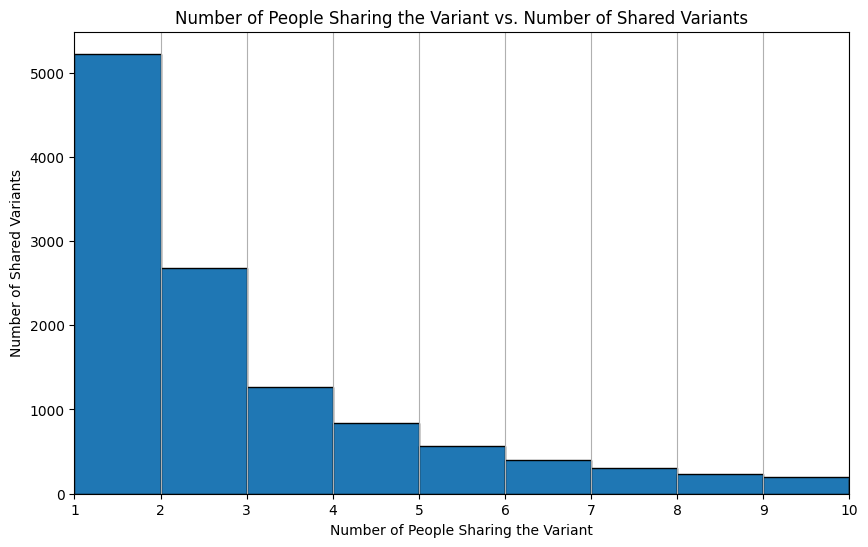

In [46]:
# Count the number of shared variants for each count of people sharing
people_sharing_counts = Counter(variant_counts) #e.g. {3: 2, 1: 1, ...} i.e. 2 counts of pple who shared 3 variants, etc

# Prepare data for plotting
x = list(people_sharing_counts.keys())
y = list(people_sharing_counts.values())

# Plotting the histogram
plt.figure(figsize=(10, 6))
plt.hist(x, bins=range(1, max(x) + 2), weights=y, edgecolor='black', orientation='vertical')
plt.xlabel('Number of People Sharing the Variant')
plt.ylabel('Number of Shared Variants')
plt.title('Number of People Sharing the Variant vs. Number of Shared Variants')
plt.xlim(1, 10)
plt.grid(axis='x')
plt.show()

In [93]:
#CHI TEST

# Filtering criteria
variant_pairs = {key: val for key, val in shared_variants.items() if len(val) == 2}

# Create a dictionary to store the count of each population for variants shared by exactly 2 people
shared_population_counts = defaultdict(int)

results = []

# Gather population counts for each variant shared by exactly 2 people
for variant, runs in variant_pairs.items():
    populations = [run_to_population[run] for run in runs]
    population_counts = Counter(populations)
    
    for pop, count in population_counts.items():
        shared_population_counts[pop] += count

# Convert the dictionary to a list of observed counts
observed_counts = list(shared_population_counts.values())
expected_counts = [(total_population_count[pop] * sum(observed_counts))**2 for pop in shared_population_counts.keys()]

# Ensure the lengths of observed and expected counts match
if len(observed_counts) == len(expected_counts):

    print(f"Observed counts: {shared_population_counts}")
    print(f"Expected counts: {expected_counts}")

    # Perform chi-square test
    chi2, p, dof, expected = chi2_contingency([observed_counts, expected_counts], correction=False)
    results.append(("Overall", p))

    # Apply Bonferroni correction
    if results:
        variants, p_values = zip(*results)
        _, corrected_p_values, _, _ = multipletests(p_values, method='bonferroni')

        results_df = pd.DataFrame({'Variant': variants, 'P-Value': p_values, 'Bonferroni': corrected_p_values})

        significant_results = results_df[results_df['Bonferroni'] < 0.05]

        results_df.to_csv('chi_square_results.csv', index=False)

Observed counts: defaultdict(<class 'int'>, {'YRI': 270, 'MSL': 138, 'MXL': 163, 'GBR': 96, 'CLM': 195, 'LWK': 182, 'BEB': 257, 'CHB': 159, 'ESN': 217, 'CEU': 327, 'GWD': 368, 'PEL': 235, 'IBS': 301, 'ITU': 136, 'CHS': 357, 'TSI': 157, 'PJL': 281, 'STU': 180, 'ACB': 195, 'GIH': 147, 'ASW': 118, 'KHV': 266, 'PUR': 211, 'FIN': 118, 'CDX': 136, 'JPT': 144})
Expected counts: [88583.75446794846, 27402.139172464435, 26306.16543962023, 23152.445106333835, 48714.91408438121, 27402.139172464435, 47979.60517688624, 29661.18707077595, 62070.69602774031, 89581.87340321732, 88583.75446794846, 41613.45163176824, 68914.94015529801, 32009.702212584965, 74282.97476514717, 32009.702212584965, 59596.36757476296, 36334.88426541657, 37620.97589069293, 29661.18707077595, 15310.082043507318, 41613.45163176824, 54018.64411296656, 27402.139172464435, 24181.31840655493, 30239.92830215032]


In [94]:
display(significant_results)

,Variant,P-Value,Bonferroni
0,Overall,7.635550e-35,7.635550e-35


In [89]:
len(total_population_count.keys()) #number of population categories is 26

26